<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
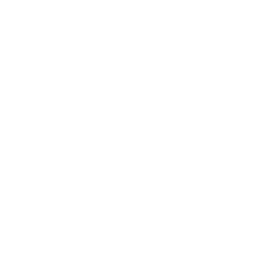
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Interpolacja rekrutacji z kwartalnej na miesięczną</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmacja / Operacje kliniczne &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie zarządcze

Ten przykład przekształca **kwartalne** liczby rekrutacji w badaniu klinicznym w estymaty **miesięczne** za pomocą PROC EXPAND, tak aby planowanie zasobów na poziomie ośrodka mogło działać w kadencji miesięcznej. Syntetyczne badanie obejmuje **cztery ośrodki badawcze** w dwóch regionach (Ameryka Północna i Europa) w ciągu **ośmiu kwartałów** (Q1 2024 do Q4 2025), co daje **32 obserwacje kwartalne**. PROC EXPAND interpoluje szereg każdego ośrodka z częstości kwartalnej na miesięczną, zamieniając te 32 wiersze kwartalne w **96 wierszy miesięcznych**. Liczby rekrutacji interpolowane są metodą `METHOD=JOIN` (kawałkami liniowa, która utrzymuje każdą estymatę nieujemną), a narastająca suma metodą `METHOD=SPLINE`. Interpolowany szereg miesięczny przechodzi dokładnie przez pierwotne kwartalne punkty zakotwiczenia, więc konwersja dodaje szczegół wewnątrzkwartalny bez zmiany figur kwartalnych, które badanie już zaraportowało.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|---------|
| WORK.ENROLLMENT_QTR | Kwartalne liczby rekrutacji według ośrodka (4 ośrodki x 8 kwartałów) | 32 |
| WORK.SITE_MASTER | Dane ośrodka: nazwa, kraj, region, główny badacz (PI) | 4 |

---

In [1]:
/* --------------------------------------------------------
   Generate quarterly enrollment counts by site.
   4 sites x 8 quarters (Q1-2024 through Q4-2025) = 32 rows.
   A ramp-up curve (slow start, plateau) plus a mild seasonal
   term and small noise produces a realistic enrollment shape.
   -------------------------------------------------------- */
DANE work.enrollment_qtr;
    DŁUGOŚĆ region $20;
    CALL streaminit(42);
    format quarter_date yyq7.;
    TABLICA capacity[4] _temporary_ (12 9 14 8);
    POWTÓRZ site_num = 1 TO 4;
        site_id = cat('SITE-', ZAPISZ(site_num, z3.));
        region  = ifc(site_num <= 2, 'Ameryka Północna', 'Europa');
        base_rate = capacity[site_num];
        POWTÓRZ qtr_seq = 0 TO 7;
            quarter_date = intnx('qtr', '01JAN2024'd, qtr_seq);
            ramp_factor  = 0.3 + 0.7 * (1 - EXP(-0.4 * qtr_seq));
            seasonal_adj = 1 + 0.15 * sin(2 * 3.14159 * qtr_seq / 4);
            noise = round(rand('normal', 0, 1.5), 1);
            enrolled_count = MAX(0,
                round(base_rate * ramp_factor * seasonal_adj + noise, 1));
            WYJŚCIE;
        KONIEC;
    KONIEC;
    USUŃ site_num base_rate ramp_factor seasonal_adj noise qtr_seq;
WYKONAJ;

/* Suma narastająca rekrutacji w obrębie każdego ośrodka */
PROCEDURA SORTUJ DANE=work.enrollment_qtr;
    WEDŁUG site_id quarter_date;
WYKONAJ;

DANE work.enrollment_qtr;
    USTAW work.enrollment_qtr;
    WEDŁUG site_id;
    PRZECHOWAJ cum_enrolled 0;
    JEŚLI first.site_id WTEDY cum_enrolled = 0;
    cum_enrolled + enrolled_count;
    cumulative_enrolled = cum_enrolled;
    USUŃ cum_enrolled;
WYKONAJ;



NOTE: DATA work.enrollment_qtr


NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.enrollment_qtr


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [2]:
/* --------------------------------------------------------
   Site master reference table (4 sites, 2 regions)
   -------------------------------------------------------- */
DANE work.site_master;
    DŁUGOŚĆ site_id $8 site_name $40 region $20 country $20 pi_name $30;
    TABLICA names[4] $40 _temporary_ (
        'Metro General Hospital'   'University Medical Center'
        'London Royal Infirmary'   'Berlin Charite Campus'
    );
    TABLICA countries[4] $20 _temporary_ ('USA' 'USA' 'UK' 'Germany');
    POWTÓRZ i = 1 TO 4;
        site_id   = cat('SITE-', ZAPISZ(i, z3.));
        site_name = names[i];
        country   = countries[i];
        region    = ifc(i <= 2, 'Ameryka Północna', 'Europa');
        pi_name   = cat('Dr. Investigator-', ZAPISZ(i, z2.));
        WYJŚCIE;
    KONIEC;
    USUŃ i;
WYKONAJ;



NOTE: DATA work.site_master


NOTE: Wrote work.site_master (4 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Baseline quarterly enrollment summary by region
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.enrollment_qtr n sum mean MAX;
    KLASA region;
    ZMIENNA enrolled_count cumulative_enrolled;
    ETYKIETA region = 'Region'
          enrolled_count = 'Liczba zrekrutowanych'
          cumulative_enrolled = 'Skumulowana liczba zrekrutowanych';
    WYJŚCIE out=work.qtr_baseline
        sum(enrolled_count)=total_enrolled
        mean(enrolled_count)=avg_per_quarter
        MAX(cumulative_enrolled)=max_cumulative;
WYKONAJ;

PROCEDURA DRUKUJ DANE=work.qtr_baseline noobs ETYKIETA;
    ETYKIETA region = 'Region'
          total_enrolled = 'Suma zrekrutowanych'
          avg_per_quarter = 'Średnia na kwartał'
          max_cumulative = 'Maksimum skumulowane';
    TYTUŁ 'Poziom bazowy rekrutacji kwartalnej według regionu';
WYKONAJ;


                                                  The MEANS Procedure

                                Analysis Variable : enrolled_count Liczba zrekrutowanych

        Region                      N Obs            Sum           Mean        Maximum
        ------------------------------------------------------------------------------
        Ameryka Północna               16    115.0000000      7.1875000     10.0000000
        Europa                         16    120.0000000      7.5000000     13.0000000
        ------------------------------------------------------------------------------

                       Analysis Variable : cumulative_enrolled Skumulowana liczba zrekrutowanych

        Region                      N Obs            Sum           Mean        Maximum
        ------------------------------------------------------------------------------
        Ameryka Północna               16    474.0000000     29.6250000     63.0000000
        Europa                         16   


NOTE: PROC MEANS
NOTE: Output dataset work.qtr_baseline has 3 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.qtr_baseline

NOTE: PROC PRINT completed: 3 observations printed, 6 variables


Poziom bazowy potwierdza zrównoważony układ: każdy region wnosi **16 obserwacji kwartalnych**. Ameryka Północna rekrutuje łącznie **115 uczestników** (średnia **7.19** na ośrodko-kwartał), a Europa **120** (średnia **7.50**). Największa suma narastająca osiągnięta w ciągu ośmiu kwartałów to **81** uczestników (europejski SITE-003) wobec **63** w Ameryce Północnej.

---

                                   Poziom bazowy rekrutacji kwartalnej według regionu                                   




NOTE: DATA work.traj


NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.traj (32 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=work.traj

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


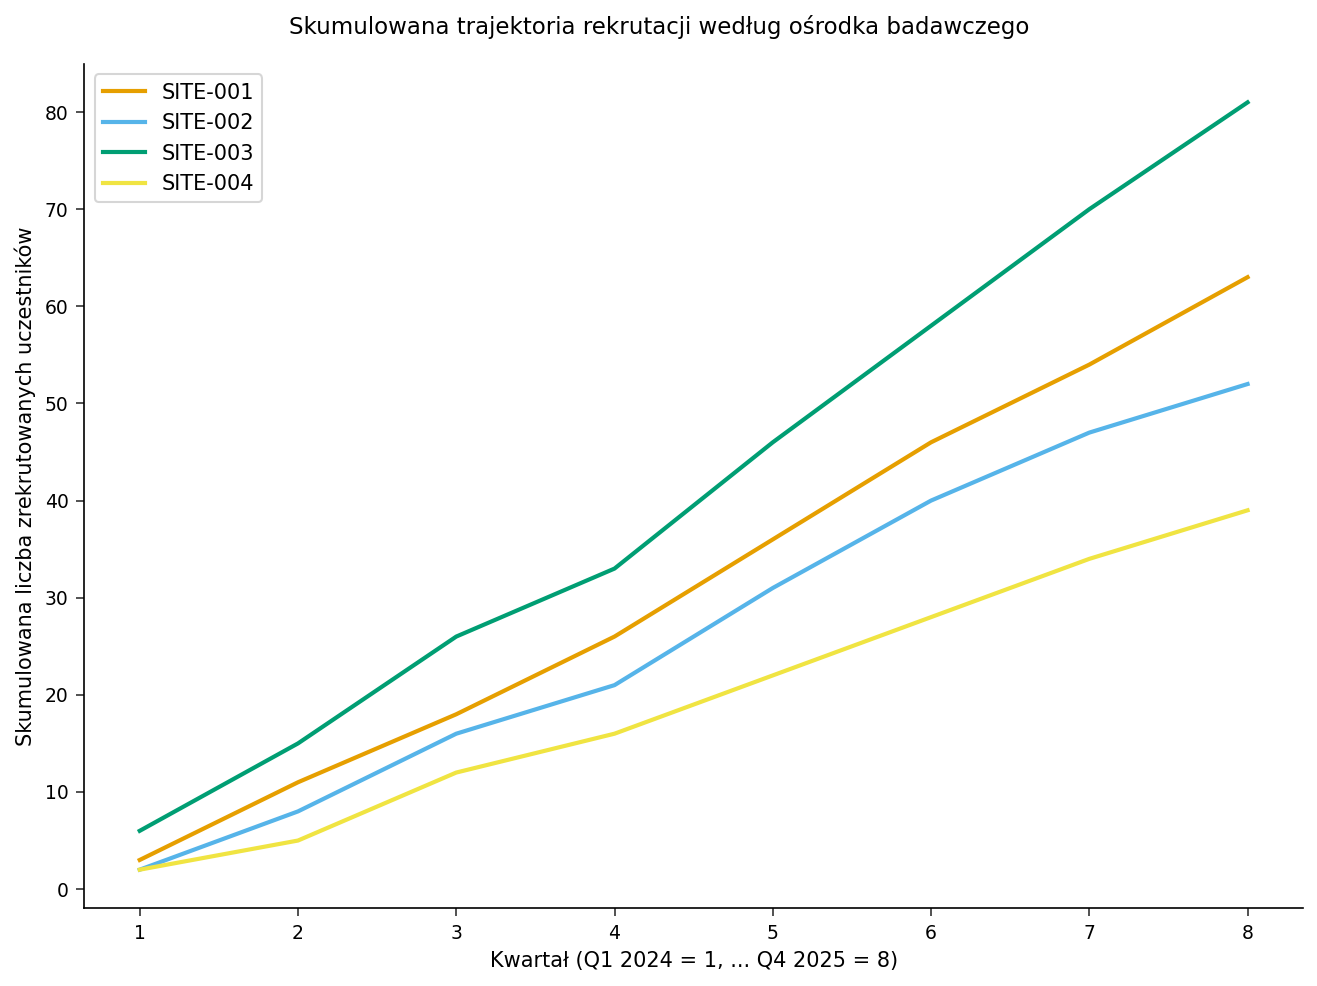

In [4]:
/* --------------------------------------------------------
   Quarterly cumulative-enrollment trajectory by site.
   Plotted against a quarter index (1..8) for a clean axis.
   -------------------------------------------------------- */
DANE work.traj;
    USTAW work.enrollment_qtr;
    WEDŁUG site_id;
    PRZECHOWAJ quarter_index 0;
    JEŚLI first.site_id WTEDY quarter_index = 0;
    quarter_index + 1;
WYKONAJ;

PROCEDURA SGPLOT DANE=work.traj;
    SERIES x=quarter_index y=cumulative_enrolled
        / GROUP=site_id LINEATTRS=(thickness=2) MARKERS;
    XAXIS ETYKIETA='Kwartał (Q1 2024 = 1, ... Q4 2025 = 8)'
        integer VALUES=(1 TO 8 WEDŁUG 1);
    YAXIS ETYKIETA='Skumulowana liczba zrekrutowanych uczestników';
    TYTUŁ 'Skumulowana trajektoria rekrutacji według ośrodka badawczego';
WYKONAJ;


---

In [5]:
/* --------------------------------------------------------
   PROC EXPAND requires the ID variable sorted within each
   BY group, so sort by site then quarter before converting.
   -------------------------------------------------------- */
PROCEDURA SORTUJ DANE=work.enrollment_qtr;
    WEDŁUG site_id quarter_date;
WYKONAJ;



NOTE: PROC SORT data=work.enrollment_qtr

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 32 rows from work.enrollment_qtr.
NOTE: Wrote work.enrollment_qtr (32 rows, 5 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Convert quarterly enrollment to monthly estimates.

   FROM=QTR / TO=MONTH on the PROC statement set the input and
   output frequencies; PROC EXPAND interpolates each BY group
   (site) independently along the ID date.

   enrolled_count   -> METHOD=JOIN   (piecewise-linear; the flow
                       value stays non-negative between anchors)
   cumulative_enrolled -> METHOD=SPLINE (smooth monotone curve)
   -------------------------------------------------------- */
PROCEDURA expand DANE=work.enrollment_qtr
            out=work.enrollment_monthly
            FROM=qtr TO=month;
    WEDŁUG site_id;
    id quarter_date;
    convert enrolled_count      / observed=average METHOD=JOIN;
    convert cumulative_enrolled / observed=KONIEC     METHOD=SPLINE;
WYKONAJ;


                                   Poziom bazowy rekrutacji kwartalnej według regionu                                   




NOTE: PROC EXPAND data=work.enrollment_qtr

NOTE: Expand Variables: enrolled_count, cumulative_enrolled
NOTE: Using Python pandas for frequency conversion
NOTE: Output dataset 'work.enrollment_monthly' has 96 observations.
NOTE: PROC EXPAND step completed.


                                   Poziom bazowy rekrutacji kwartalnej według regionu                                   




NOTE: DATA work.enrollment_monthly


NOTE: Read 96 rows from work.enrollment_monthly.
NOTE: Wrote work.enrollment_monthly (96 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SGPLOT data=work.enrollment_monthly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


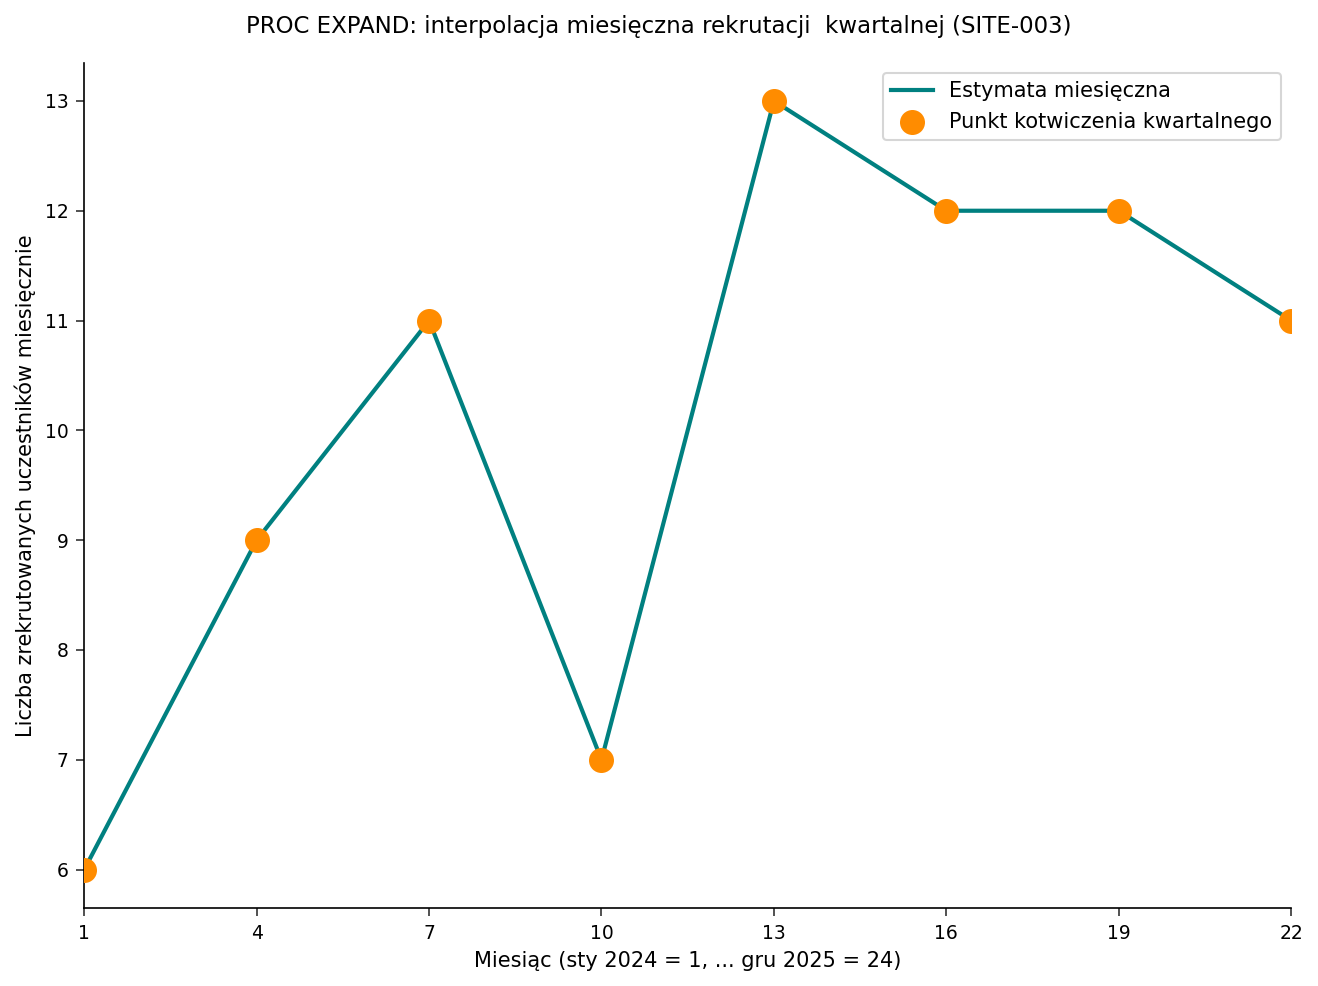

In [7]:
/* --------------------------------------------------------
   The ID variable now carries monthly dates. Re-format it and
   add a within-site month index (1..24) for plotting.
   -------------------------------------------------------- */
DANE work.enrollment_monthly;
    USTAW work.enrollment_monthly;
    WEDŁUG site_id;
    format month_date monyy7.;
    month_date = quarter_date;
    PRZECHOWAJ month_index 0;
    JEŚLI first.site_id WTEDY month_index = 0;
    month_index + 1;
    /* flag the quarter-anchor months (1, 4, 7, ...) */
    JEŚLI mod(month_index - 1, 3) = 0 WTEDY anchor = enrolled_count;
    PRZECIWNIE anchor = .;
WYKONAJ;

/* Show the conversion for one site: interpolated monthly line
   passing through the original quarterly anchor points. */
PROCEDURA SGPLOT DANE=work.enrollment_monthly;
    GDZIE site_id = 'SITE-003';
    SERIES x=month_index y=enrolled_count
        / LINEATTRS=(thickness=2 color=teal)
          legendlabel='Estymata miesięczna';
    SCATTER x=month_index y=anchor
        / MARKERATTRS=(SYMBOL=circlefilled size=11 color=darkorange)
          legendlabel='Punkt kotwiczenia kwartalnego';
    XAXIS ETYKIETA='Miesiąc (sty 2024 = 1, ... gru 2025 = 24)'
        integer VALUES=(1 TO 24 WEDŁUG 3);
    YAXIS ETYKIETA='Liczba zrekrutowanych uczestników miesięcznie';
    TYTUŁ 'PROC EXPAND: interpolacja miesięczna rekrutacji '
        'kwartalnej (SITE-003)';
WYKONAJ;


In [8]:
/* --------------------------------------------------------
   Join the monthly estimates to site metadata, then summarize
   monthly enrollment by region.
   -------------------------------------------------------- */
PROCEDURA SQL;
    CREATE TABLE work.enrollment_monthly_region AS
    WYBIERZ e.site_id, s.region, e.month_date,
           e.enrolled_count      AS monthly_estimate,
           e.cumulative_enrolled AS cumulative_estimate
    FROM work.enrollment_monthly e
    INNER JOIN work.site_master s
        ON e.site_id = s.site_id
    ORDER WEDŁUG s.region, e.site_id, e.month_date;
QUIT;

PROCEDURA ŚREDNIE DANE=work.enrollment_monthly_region n sum mean;
    KLASA region;
    ZMIENNA monthly_estimate cumulative_estimate;
    ETYKIETA region = 'Region'
          monthly_estimate = 'Estymata miesięczna'
          cumulative_estimate = 'Estymata skumulowana';
    WYJŚCIE out=work.region_monthly_summary
        sum(monthly_estimate)=total_monthly_enrolled
        mean(monthly_estimate)=avg_monthly_rate;
WYKONAJ;

PROCEDURA DRUKUJ DANE=work.region_monthly_summary noobs ETYKIETA;
    ETYKIETA region = 'Region'
          total_monthly_enrolled = 'Suma rekrutacji miesięcznej'
          avg_monthly_rate = 'Średnia stopa miesięczna';
    TYTUŁ 'Estymaty miesięczne według regionu';
WYKONAJ;


                                   Poziom bazowy rekrutacji kwartalnej według regionu                                   

                                   Poziom bazowy rekrutacji kwartalnej według regionu                                   

                                                  The MEANS Procedure

                               Analysis Variable : monthly_estimate Estymata miesięczna

        Region                      N Obs            Sum           Mean
        ---------------------------------------------------------------
        Ameryka Północna               44    326.0000000      7.4090909
        Europa                         44    336.0000000      7.6363636
        ---------------------------------------------------------------

                              Analysis Variable : cumulative_estimate Estymata skumulowana

        Region                      N Obs            Sum           Mean
        ---------------------------------------------------------------


NOTE: PROC SQL 

NOTE: Table work.enrollment_monthly_region created.
NOTE: PROC SQL statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.region_monthly_summary has 3 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.region_monthly_summary

NOTE: PROC PRINT completed: 3 observations printed, 5 variables


---

### Interpretacja

PROC EXPAND przekształcił **32 rekordy kwartalne** (4 ośrodki x 8 kwartałów) w **96 rekordów miesięcznych** za pomocą konwersji częstości wzdłuż daty każdego ośrodka. Interpolowany szereg miesięczny przechodzi dokładnie przez pierwotne kwartalne wartości zakotwiczenia, co pokazuje wykres SITE-003: pomarańczowe punkty to osiem zaraportowanych liczb kwartalnych, a turkusowa linia to zdezagregowana estymata miesięczna, która je łączy.

W ujęciu miesięcznym oba regiony podążają blisko siebie. Europa ma średnio **7.64** zrekrutowanego uczestnika na ośrodko-miesiąc, a Ameryka Północna **7.41**, przy regionalnych sumach miesięcznych **336** i **326** uczestników w interpolowanym horyzoncie. Ponieważ `METHOD=JOIN` nie ekstrapoluje poza ostatnie kwartalne zakotwiczenie, końcowe miesiące niepełnego kwartału nie niosą estymaty i są wyłączone ze średnich miesięcznych, co jest zachowawczym wyborem dla planowania w przód.

Te projekcje miesięczne pozwalają operacjom klinicznym przejść z kwartalnej na miesięczną kadencję planowania -- wymiarowanie dostaw leków, harmonogramowanie wizyt monitorujących i raportowanie rekrutacji do Rady Monitorowania Bezpieczeństwa Danych (DSMB) -- bez korygowania jakichkolwiek figur kwartalnych, które badanie już zablokowało.

---

In [9]:
/* --------------------------------------------------------
   Export monthly enrollment projections for downstream
   planning tools.
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.enrollment_monthly_region
    OUTFILE='monthly_enrollment_projections.csv'
    DBMS=csv REPLACE;
WYKONAJ;

PROCEDURA EKSPORTUJ DANE=work.region_monthly_summary
    OUTFILE='region_monthly_enrollment_summary.csv'
    DBMS=csv REPLACE;
WYKONAJ;



NOTE: PROC EXPORT data=work.enrollment_monthly_region outfile=monthly_enrollment_projections.csv

NOTE: Exported 96 rows to monthly_enrollment_projections.csv.
NOTE: PROC EXPORT data=work.region_monthly_summary outfile=region_monthly_enrollment_summary.csv

NOTE: Exported 3 rows to region_monthly_enrollment_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>